script de visualisation (ROIs et la matrice de corrélation) pour tous les sujets

In [1]:
from nilearn import datasets, plotting
import matplotlib.pyplot as plt
import numpy as np

In [2]:
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, resolution_mm=2)
atlas_img = atlas.maps
labels = atlas.labels

[fetch_atlas_schaefer_2018] Dataset found in /home/etudiants/nilearn_data/schaefer_2018

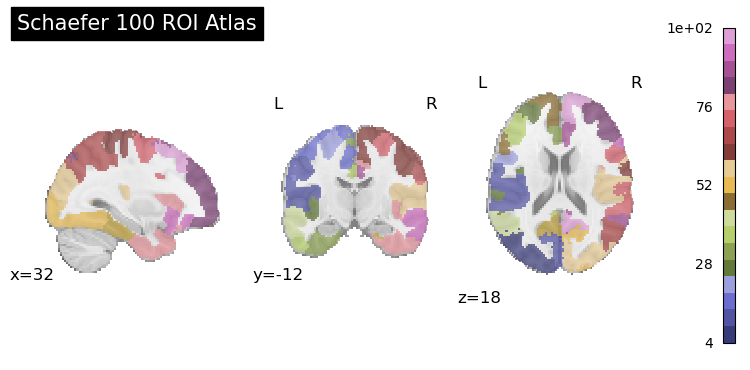

In [3]:
plotting.plot_roi(atlas_img, title='Schaefer 100 ROI Atlas', draw_cross=False, cmap='tab20b')

In [4]:
X_all = np.load("X_all.npy")

In [5]:
n_rois = 100
n_trials = X_all.shape[0]
X_full = np.zeros((n_trials, n_rois, n_rois))

triu_indices = np.triu_indices(n_rois, k=1)
for i in range(n_trials):
    mat = np.zeros((n_rois, n_rois))
    mat[triu_indices] = X_all[i]
    mat += mat.T
    X_full[i] = mat

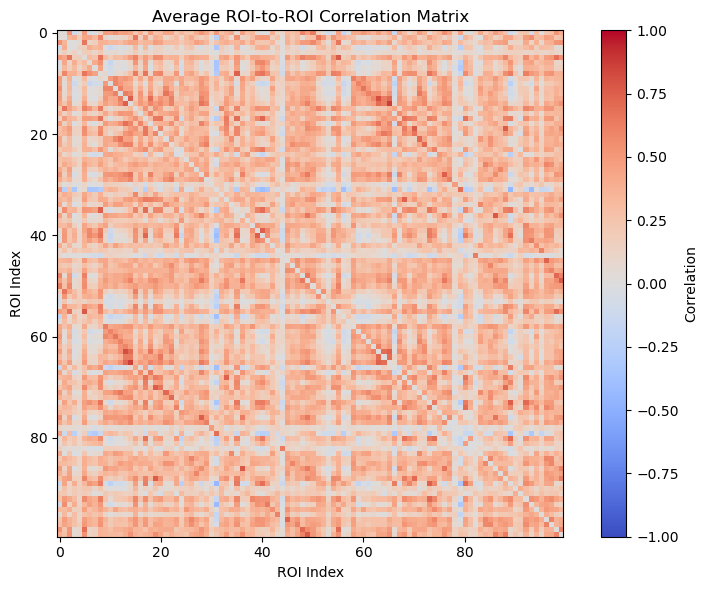

In [9]:
avg_corr = np.nanmean(X_full, axis=0)

plt.figure(figsize=(8, 6))
plt.imshow(avg_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Average ROI-to-ROI Correlation Matrix")
plt.colorbar(label="Correlation")
plt.xlabel("ROI Index")
plt.ylabel("ROI Index")
plt.tight_layout()
plt.show()